In [7]:
from pathlib import Path
from google.colab import drive

# Monta o Google Drive e centraliza todos os caminhos usados pelo notebook.
drive.mount('/content/drive')

DRIVE_PROJECT_ROOT = Path('/content/drive/MyDrive/mestrado-arvores-urbanas')
RAW_DATA_DIR = DRIVE_PROJECT_ROOT / 'data' / 'raw'
INTERIM_DATA_DIR = DRIVE_PROJECT_ROOT / 'data' / 'interim'
RESULTS_DIR = DRIVE_PROJECT_ROOT / 'outputs'

path_img = RAW_DATA_DIR / 'AOI.tif'
path_img_mult = RAW_DATA_DIR / 'AOI_MULTI.tif'
path_aoi = RAW_DATA_DIR / 'AOI.shp'
path_grama = RAW_DATA_DIR / 'Grama.shp'
path_arvore = RAW_DATA_DIR / 'Arvores.shp'
path_linhas = RAW_DATA_DIR / 'Linhas.shp'
path_postes = RAW_DATA_DIR / 'Postes.shp'

INTERIM_DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

polygons_output_path = RESULTS_DIR / 'polygons.json'
features_stack_path = INTERIM_DATA_DIR / 'features_stack.tif'
segmented_trees_output_path = RESULTS_DIR / 'arvores_segmentadas.json'

required_input_paths = {
    'imagem RGB': path_img,
    'imagem multiespectral': path_img_mult,
    'área de interesse': path_aoi,
    'amostras de grama': path_grama,
    'amostras de árvores': path_arvore,
    'linhas de energia': path_linhas,
    'postes': path_postes,
}
missing_input_paths = {
    name: path for name, path in required_input_paths.items() if not path.exists()
}
if missing_input_paths:
    missing_list = '\n'.join(
        f'  - {name}: {path}' for name, path in missing_input_paths.items()
    )
    raise FileNotFoundError(
        'Arquivos de entrada ausentes no Google Drive:\n'
        f'{missing_list}\n'
        'Envie os arquivos para a estrutura descrita em data/README.md '
        'e execute esta célula novamente.'
    )

print(f'Configuração concluída. Dados carregados de: {RAW_DATA_DIR}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Configuração concluída. Dados carregados de: /content/drive/MyDrive/mestrado-arvores-urbanas/data/raw


In [2]:
from skimage.segmentation import felzenszwalb, slic, quickshift, watershed
from skimage.segmentation import mark_boundaries
from skimage.util import img_as_float
from skimage.filters import sobel
from skimage.color import rgb2gray
from skimage import color
import rasterio
from matplotlib import pyplot as plt
import numpy as np
import geopandas as gpd
import pandas as pd
from rasterio.plot import show

Abrir a imagem com o rasterio, convertendo num numpy array:

In [6]:
src_rgb = rasterio.open(path_img)
im = src_rgb.read()
im = im.transpose([1,2,0])

Plotando a imagem com o matplotlib:

(np.float64(-0.5), np.float64(2758.5), np.float64(2670.5), np.float64(-0.5))

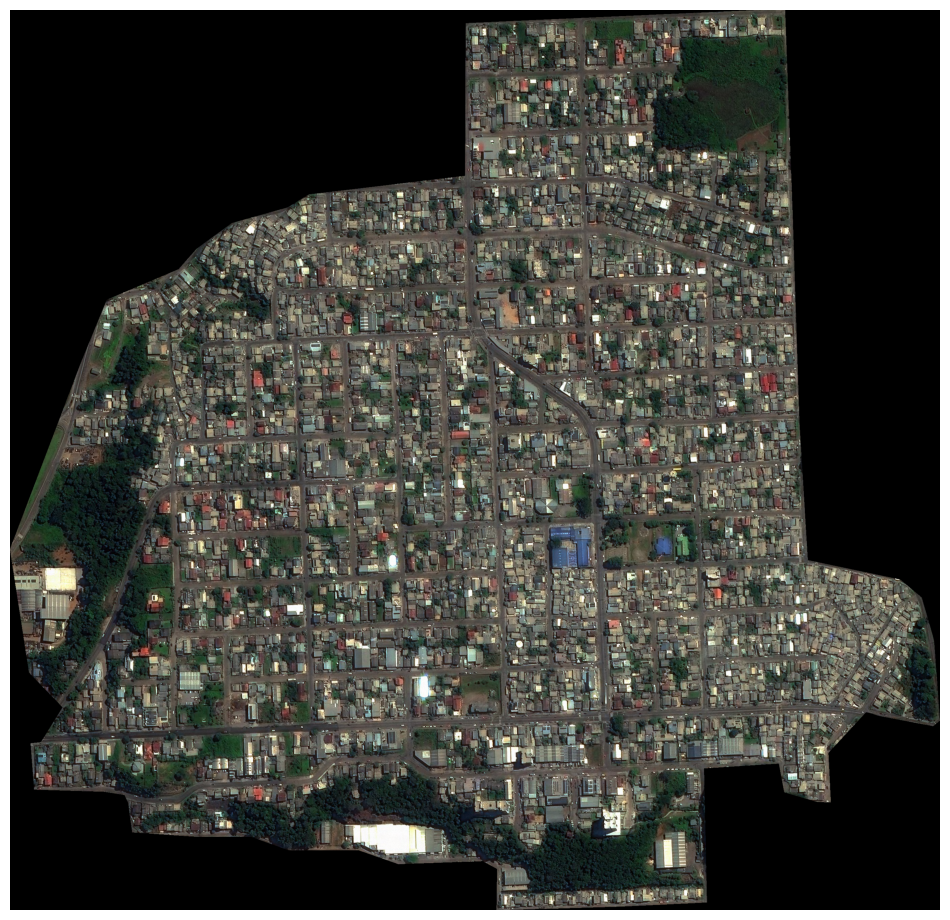

In [4]:
plt.figure(figsize=[12,12])
plt.imshow(im)
plt.axis('off')

Abrir o poligono da área de interesse:

In [5]:
AOI = gpd.read_file(path_aoi)

## Segmentação:

Aplicação do quickshift (Ver artigos relacionados)

In [ ]:
segments_quick2 = quickshift(im, kernel_size=3, max_dist=5, ratio=0.04)

In [ ]:
plt.figure(figsize=[16,16])
plt.imshow(mark_boundaries(im, segments_quick2))
plt.axis('off')

In [ ]:
segments_quick2 = segments_quick2.astype('uint16')

Conversão para poligono e extração das caracteristicas espectrais:

In [ ]:
from rasterio import features
from shapely.geometry import shape
import geopandas as gpd
import shapely
import json
from rasterio.mask import mask
import pandas as pd

Primeiro, converter os segmentos em poligonos usando geopandas e rasterio:

In [ ]:
find_shapes = features.shapes(segments_quick2, transform=src_rgb.transform)

In [ ]:
polygons = [shapely.geometry.Polygon(shape[0]["coordinates"][0]) for shape in find_shapes]

In [ ]:
crs = src_rgb.crs
Poly_gdf = gpd.GeoDataFrame(crs=crs, geometry=polygons)

Salvar os poligonos em um JSON:

In [ ]:
Poly_gdf.to_file(polygons_output_path)

In [ ]:
Poly_gdf.boundary.plot()

Obter somente os poligonos da área de interesse:

In [ ]:
clip_poly = Poly_gdf.clip(AOI)

In [ ]:
clip_poly.boundary.plot()

Extrair a média espectral de cada segmento:

In [ ]:
clip_poly = clip_poly.reset_index(drop=True)

In [ ]:
json_dataset = json.loads(clip_poly.to_json())['features']

In [ ]:
src = rasterio.open(path_img_mult)

X = []
Y = []
for i in range(len(json_dataset)):
  coords = json_dataset[i]['geometry']
  out_image, out_transform = mask(src, [coords], crop=True, nodata=0)

  out_image = out_image.transpose([1,2,0])

  R_mean = out_image[:,:,0][np.nonzero(out_image[:,:,0])].mean()
  G_mean = out_image[:,:,1][np.nonzero(out_image[:,:,1])].mean()
  B_mean = out_image[:,:,2][np.nonzero(out_image[:,:,2])].mean()
  N_mean = out_image[:,:,3][np.nonzero(out_image[:,:,3])].mean()
  R_std = out_image[:,:,0][np.nonzero(out_image[:,:,0])].std()
  G_std = out_image[:,:,1][np.nonzero(out_image[:,:,1])].std()
  B_std = out_image[:,:,2][np.nonzero(out_image[:,:,2])].std()
  N_std = out_image[:,:,3][np.nonzero(out_image[:,:,3])].std()




  X.append([R_mean,G_mean,B_mean,N_mean,R_std,G_std,B_std,N_std])

In [ ]:
X = np.array(X)

## Aplicação do K-Means

Geramos o dataframe com a informação das médias espectrais por segmentos:

In [ ]:
df = pd.DataFrame(X, columns=['R_Mean','G_Mean','B_Mean','N_Mean','R_Std', 'G_Std', 'B_Std', 'N_Std'])

In [ ]:
df

In [ ]:
df.dropna(inplace=True)

Aplicamos o Kmeans:

In [ ]:
from sklearn.cluster import KMeans

# Apply K-Means clustering
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10) # You can change the number of clusters
kmeans_clusters = kmeans.fit_predict(df[['R_Mean','G_Mean','B_Mean','N_Mean','R_Std', 'G_Std', 'B_Std', 'N_Std']])

# Add K-Means cluster labels to the DataFrame
df['kmeans_cluster'] = kmeans_clusters

display(df.head())

Aplicamos o resultado do Kmeans para os segmentos e visualizamos:

In [ ]:
clip_poly['kmeans_cluster'] = df['kmeans_cluster']

In [ ]:
import matplotlib.pyplot as plt

# Plot the GeoDataFrame, colored by cluster
fig, ax = plt.subplots(1, 1, figsize=(15, 15))
clip_poly.plot(column='kmeans_cluster', ax=ax, legend=True, cmap='magma') # Changed colormap to 'viridis'
plt.title('Polygons Colored by kmeans_cluster')
plt.axis('off')
plt.show()

Salvamos o resultado em um JSON:

In [ ]:
Poly_gdf.to_file(polygons_output_path)

Selecionamos somente o cluster de arvores:

In [ ]:
import rasterio.plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(15, 15))
rasterio.plot.show(src_rgb, ax=ax)
clip_poly[clip_poly['kmeans_cluster'] == 0].boundary.plot(ax=ax, color='red')
plt.title('Original Image')
plt.axis('off')
plt.show()

In [ ]:
# Caminhos definidos na célula de configuração inicial.

In [ ]:
gdf_grama = gpd.read_file(path_grama)
gdf_arvore = gpd.read_file(path_arvore)

In [ ]:
gdf_grama['Classe'] = 'grama'
gdf_arvore['Classe'] = 'arvore'

In [ ]:
gdf_full = pd.concat([gdf_grama, gdf_arvore])

In [ ]:
gdf_arvore_seg = clip_poly[clip_poly['kmeans_cluster'] == 0]

In [ ]:
gdf_arvore_seg_filter = gdf_arvore_seg.sjoin(gdf_full, how='inner', predicate='intersects')

In [ ]:
gdf_arvore_seg_filter.plot()

In [ ]:
gdf_arvore_seg_filter

In [ ]:
src = rasterio.open(path_img_mult)

In [ ]:
img = src.read()

In [ ]:
img.shape

In [ ]:
nir = img[3]
red = img[0]

In [ ]:
nir.shape

In [ ]:
plt.figure(figsize=(10, 10))
plt.imshow(nir, cmap='gray')
plt.title('NIR Band')
plt.axis('off')
plt.show()

In [ ]:
import numpy as np

# Calculate NDVI
# Avoid division by zero by adding a small epsilon to the denominator
ndvi = (nir.astype(float) - red.astype(float)) / (nir.astype(float) + red.astype(float) + 1e-8)

# Plot NDVI
plt.figure(figsize=(10, 10))
plt.imshow(ndvi, cmap='RdYlGn', vmin=0, vmax=1) # RdYlGn is a common colormap for NDVI
plt.colorbar(label='NDVI Value')
plt.title('Normalized Difference Vegetation Index (NDVI)')
plt.axis('off')
plt.show()

In [ ]:
nir.max()

In [ ]:
from skimage.feature import canny
from skimage.util import img_as_ubyte

# Ensure nir is in the correct format (uint8) for Canny
nir_uint = nir/10000

# Apply Canny edge detection
edges = canny(nir_uint, sigma=1)

# Plot the edges
plt.figure(figsize=(10, 10))
plt.imshow(edges, cmap='gray')
plt.title('Canny Edges of NIR Band')
plt.axis('off')
plt.show()

In [ ]:
img_rgb = img[0:3]

In [ ]:
img_rgb = img_rgb.transpose([1,2,0])

In [ ]:
from skimage.color import rgb2hsv

# Convert RGB to HSV
img_hsv = rgb2hsv(img_rgb)

# Extract the intensity (Value) channel, which is the third channel (index 2)
intensity = img_hsv[:, :, 2]

# Display the intensity image
plt.figure(figsize=(10, 10))
plt.imshow(intensity, cmap='gray')
plt.title('Intensity Channel (HSV)')
plt.axis('off')
plt.show()

In [ ]:
# Convert edges (boolean) to float for stacking
edges_float = edges.astype(np.float32)

# Stack intensity and edges as two separate bands
# The order here is intensity first, then edges
stacked_bands = np.stack([intensity, edges_float, ndvi], axis=0)

# Get metadata from the original source (src) for writing the new TIFF
profile = src.profile

# Update profile for the new stacked image
# Change the number of bands to 2 and data type to float32
profile.update(
    dtype=rasterio.float32,
    count=3,
    nodata=None
)

# Define the output path for the new TIFF file
output_filepath = features_stack_path

# Write the stacked image to a new TIFF file
with rasterio.open(output_filepath, 'w', **profile) as dst:
    dst.write(stacked_bands)


In [ ]:
src = rasterio.open(output_filepath)
json_dataset = json.loads(gdf_arvore_seg_filter.to_json())['features']

X = []
for i in range(len(json_dataset)):
  coords = json_dataset[i]['geometry']
  out_image, out_transform = mask(src, [coords], crop=True, nodata=-999)
  classe_values = json_dataset[i]['properties']['Classe']

  mean_intensity = out_image[0][out_image[0] != -999].mean()
  mean_edges = out_image[1][out_image[1] != -999].mean()
  mean_ndvi = out_image[2][out_image[2] != -999].mean()
  X.append([mean_intensity, mean_edges, mean_ndvi,classe_values])


In [ ]:
df = pd.DataFrame(X, columns=['mean_intensity','mean_edges','mean_ndvi','classe'])

In [ ]:
import seaborn as sns

# Create a pairplot with 'classe' as hue
sns.pairplot(df, hue='classe')
plt.show()

In [ ]:
df

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# Separate features (X) and target (y)
X = df.drop('classe', axis=1) # Features are all columns except 'classe'
y = df['classe'] # Target is the 'classe' column

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Random Forest Classifier
# You can adjust parameters like n_estimators (number of trees) as needed
rf_classifier = RandomForestClassifier(n_estimators=500, random_state=42)

# Train the model
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
print("Random Forest Classifier Report:")
print(classification_report(y_test, y_pred))
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2f}")

In [ ]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=rf_classifier.classes_)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_classifier.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [ ]:
src = rasterio.open(output_filepath)
json_dataset = json.loads(gdf_arvore_seg.to_json())['features']

X_pred = []
for i in range(len(json_dataset)):
  coords = json_dataset[i]['geometry']
  out_image, out_transform = mask(src, [coords], crop=True, nodata=-999)

  mean_intensity = out_image[0][out_image[0] != -999].mean()
  mean_edges = out_image[1][out_image[1] != -999].mean()
  mean_ndvi = out_image[2][out_image[2] != -999].mean()
  X_pred.append([mean_intensity, mean_edges, mean_ndvi])

In [ ]:
df_pred = pd.DataFrame(X_pred, columns=['mean_intensity','mean_edges','mean_ndvi'])

In [ ]:
gdf_arvore_seg['predicted_classe'] = rf_classifier.predict(df_pred)

In [ ]:
gdf_arvore_seg

In [ ]:
gdf_arvore_seg['area'] = gdf_arvore_seg.area

In [ ]:
tree_polys = gdf_arvore_seg.copy()

In [ ]:
import numpy as np

#C1
a1 = 0.5
b1 = 0.7
tree_polys['Power_tree_size_C1'] = a1 * (tree_polys['area'] ** b1)
tree_polys['Linear_tree_size_C1'] = a1 + (tree_polys['area'] * b1)


#C2
a2 = 0.6
b2 = 0.8
tree_polys['Power_tree_size_C2'] = a2 * (tree_polys['area'] ** b2)
tree_polys['Linear_tree_size_C2'] = a2 + (tree_polys['area'] * b2)


#C3
a3 = 2.5
b3 = 0.4
tree_polys['Power_tree_size_C3'] = a3 * (tree_polys['area'] ** b3)
tree_polys['Linear_tree_size_C3'] = a3 + (tree_polys['area'] * b3)

#C4
a4 = 4
b4 = 0.5
tree_polys['Power_tree_size_C4'] = a4 * (tree_polys['area'] ** b4)
tree_polys['Linear_tree_size_C4'] = a4 + (tree_polys['area'] * b4)

#C5

a5 = 0.4
b5 = 0.9
tree_polys['Power_tree_size_C5'] = a5 * (tree_polys['area'] ** b5)
tree_polys['Linear_tree_size_C5'] = a5 + (tree_polys['area'] * b5)



a6 = 1.35
b6 = 0.72
tree_polys['Power_tree_size_C6'] = a6 * (tree_polys['area'] ** b6)
tree_polys['Linear_tree_size_C6'] = a6 + (tree_polys['area'] * b6)

In [ ]:
tree_polys

In [ ]:
columns = ['Power_tree_size_C1', 'Linear_tree_size_C1', 'Power_tree_size_C2', 'Linear_tree_size_C2',
           'Power_tree_size_C3', 'Linear_tree_size_C3', 'Power_tree_size_C4', 'Linear_tree_size_C4',
           'Power_tree_size_C5', 'Linear_tree_size_C5', 'Power_tree_size_C6', 'Linear_tree_size_C6']

In [ ]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=tree_polys[columns])
plt.title('Box Plot of Tree Size Metrics for Different Constants')
plt.ylabel('Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=tree_polys['Power_tree_size_C3'])
plt.title('Box Plot of Tree Size Metrics for C3')
plt.ylabel('Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(tree_polys['Power_tree_size_C3'], bins=30, edgecolor='black')
plt.title('Histogram of Power_tree_size_C3')
plt.xlabel('Power_tree_size_C3')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
filter_tree = tree_polys[tree_polys['Power_tree_size_C3'] > 7]

In [ ]:
filter_tree.to_file(segmented_trees_output_path)

## Análise das arvores proximas a linhas e postes:

Importação e visualização das linhas e postes:

In [ ]:
Linhas = gpd.read_file(path_linhas)

In [ ]:
Postes = gpd.read_file(path_postes)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(15, 15))
rasterio.plot.show(src_rgb, ax=ax)
filter_tree.boundary.plot(ax=ax, color='green')
Linhas.plot(ax=ax, color='red')
Postes.plot(ax=ax, color='blue')
plt.title('Original Image')
plt.axis('off')
plt.show()

Arvores maiores que 7m proximas a linhas:

In [ ]:
arvores_inter_linhas = gpd.sjoin(filter_tree, Linhas, how="inner")

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(15, 15))
rasterio.plot.show(src_rgb, ax=ax)
arvores_inter_linhas.boundary.plot(ax=ax, color='green')
Linhas.plot(ax=ax, color='red')
plt.title('Original Image')
plt.axis('off')
plt.show()

Arvores maiores que 7m a 1m de distancia ou menos de postes:

In [ ]:
arvores_prox_linhas = gpd.sjoin_nearest(filter_tree, Linhas, max_distance=1)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(15, 15))
rasterio.plot.show(src_rgb, ax=ax)
arvores_prox_linhas.boundary.plot(ax=ax, color='green')
Linhas.plot(ax=ax, color='blue')
plt.title('Original Image')
plt.axis('off')
plt.show()

Arvores maiores que 7m a 3m de distancia ou menos de postes:

In [ ]:
arvores_prox_linhas_3m = gpd.sjoin_nearest(filter_tree, Linhas, max_distance=3)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(15, 15))
rasterio.plot.show(src_rgb, ax=ax)
arvores_prox_linhas_3m.boundary.plot(ax=ax, color='green')
Linhas.plot(ax=ax, color='blue')
plt.title('Original Image')
plt.axis('off')
plt.show()

Arvores maiores que 7m a 5m de distancia ou menos de postes:

In [ ]:
arvores_prox_linhas_5m = gpd.sjoin_nearest(filter_tree, Linhas, max_distance=5)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(15, 15))
rasterio.plot.show(src_rgb, ax=ax)
arvores_prox_linhas_5m.boundary.plot(ax=ax, color='green')
Linhas.plot(ax=ax, color='blue')
plt.title('Original Image')
plt.axis('off')
plt.show()